### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [10]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [11]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [12]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [13]:
## Initialize LLM model 
from langchain_groq import ChatGroq
llm = ChatGroq(model="meta-llama/llama-4-maverick-17b-128e-instruct", temperature=0)
llm
 

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028B7C80F560>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028B7C7546B0>, model_name='meta-llama/llama-4-maverick-17b-128e-instruct', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [18]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

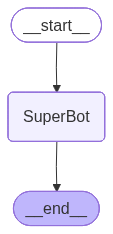

In [19]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [20]:
## Invocation
config = {"configurable": {"thread_id": "1"}}
graph_builder.invoke({'messages':"Hi,My name is Harry And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Harry And I like cricket', additional_kwargs={}, response_metadata={}, id='2daeaba8-5ca7-4ab7-ad1d-3d34e838e0cb'),
  AIMessage(content="Hello Harry! Nice to meet you! Cricket is a fantastic sport, isn't it? Do you have a favorite team or player? Are you a fan of Test cricket, One-Day Internationals, or Twenty20?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 20, 'total_tokens': 65, 'completion_time': 0.085689033, 'completion_tokens_details': None, 'prompt_time': 0.355065374, 'prompt_tokens_details': None, 'queue_time': 0.240471302, 'total_time': 0.440754407}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_217b6e6136', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c164a-0c07-7fd0-8cd4-7c9a374606bc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'o

#### Streaming The Responses With Stream Method

In [23]:
# Create a Thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Alice And I like football"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Alice, nice to meet you! Football is a great sport, isn't it? Do you have a favorite team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 80, 'total_tokens': 107, 'completion_time': 0.045295284, 'completion_tokens_details': None, 'prompt_time': 0.104298671, 'prompt_tokens_details': None, 'queue_time': 1.23292051, 'total_time': 0.149593955}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c164c-04f3-7291-8de0-0fe4e97f4ae9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 80, 'output_tokens': 27, 'total_tokens': 107})]}}


In [27]:
# config = {"configurable": {"thread_id": "2"}}
import pprint 
for chunk in graph_builder.stream({'messages':"Hi,My name is Alice And I like Cricket"},config,stream_mode="values"):
    pprint.pprint(chunk)

{'messages': [HumanMessage(content='Hi,My name is Alice And I like football', additional_kwargs={}, response_metadata={}, id='e6f5ab45-ae15-40f8-b477-e94e14512104'),
              AIMessage(content="Nice to meet you, Alice! That's great to hear that you like football! Are you a fan of a particular team or league? Do you play football yourself or watch matches with friends and family?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 20, 'total_tokens': 61, 'completion_time': 0.084584442, 'completion_tokens_details': None, 'prompt_time': 0.028227711, 'prompt_tokens_details': None, 'queue_time': 1.620860768, 'total_time': 0.112812153}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_992318f10a', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c164b-d1ab-7633-864e-69724a86335c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata=

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [ ]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019c164f-894b-7550-ae46-f754a629021f', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='ccc1715a-131b-444f-88a2-257a20839fe4')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019c164f-8951-7d92-8239-b42040d30bc8', 'metadata': {'thread_id': '3', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:e7eb8925-eec9-55cc-b5bc-9b10e05c0337'}, 'parent_ids': ['019c164f-894b-7550-ae46-f754a629021f']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi My name is Krish and I like to pla

: 